# 08 · Experimento A/B/n: ¿qué tipo de apoyo convierte una oportunidad en exportación?

**Fase CRISP-DM:** tercera iteración, que pasa de describir y predecir a **probar una intervención** (pregunta 6
del proyecto): comprensión del negocio (qué decisión se quiere tomar), diseño del experimento (preregistro,
tamaño muestral, aleatorización), evaluación (análisis y validación del procedimiento) y despliegue (regla de
decisión).

### Qué es real y qué es simulado
Este es un experimento **semi-sintético**: no se ejecutó en el mundo real, y lo digo desde el principio.

| Componente | Origen |
|---|---|
| Población: 10.000 oportunidades (pares producto–país que Chile no exportaba en 2025) | **Real** (candidatos del notebook 02) |
| Covariables previas: puntaje del modelo con grafo, comercio del par en 2024 y 2025 | **Real** |
| Resultado sin tratamiento, Y(0): si el par se exportó (≥ US$ 10.000) en ene–ago 2026, mes a mes | **Real** |
| Asignación de cada oportunidad a un brazo | Aleatoria, como en un experimento real |
| Efecto de cada tratamiento, Y(1) | **Supuesto declarado**, inyectado sobre Y(0) |

Como el grupo control usa resultados reales, todo lo que depende del ruido de los datos es real: la varianza,
la correlación dentro de cada producto, cuánto ayudan las covariables y cómo evoluciona el resultado mes a mes.
Lo único inventado es el tamaño del efecto. Por eso, el valor de este notebook está en el **diseño y el análisis**
(que se validan contra un efecto verdadero conocido), no en afirmar que alguna campaña funciona.

### El escenario
Una agencia de promoción de exportaciones tiene un listado de oportunidades: mercados donde un producto chileno
tiene capacidades relacionadas (red del notebook 02) pero todavía no se vende. Quiere saber qué tipo de apoyo
sirve antes de escalarlo, y prueba tres en paralelo:

| Brazo | Tratamiento | Costo supuesto por oportunidad |
|---|---|---|
| A | Control: sin apoyo | US$ 0 |
| B | Alerta informativa (correo con datos del mercado) | US$ 50 |
| C | Rueda de negocios con compradores del país | US$ 1.500 |
| D | Rueda de negocios + misión comercial | US$ 4.000 |

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from comercio_chile import viz, experiment as E

viz.setup(); warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)

u = E.opportunities(10_000)
y0 = u.activa.to_numpy().astype(float)
cluster = u.hs6.to_numpy()
X = u[E.COVARIATES].to_numpy()
months = [c for c in u.columns if c.startswith("activa_")]
p0 = y0.mean()
print(f"{len(u):,} oportunidades en {u.hs6.nunique():,} productos y {u.pais.nunique()} países")
print(f"Tasa de activación real sin apoyo (ene–ago 2026): {p0:.1%}")

10,000 oportunidades en 1,110 productos y 166 países
Tasa de activación real sin apoyo (ene–ago 2026): 10.3%


## 1. Preregistro: las decisiones que se toman antes de ver los datos

Fijar todo esto antes de mirar resultados es lo que separa un experimento de una búsqueda de resultados
significativos.

- **Hipótesis:** cada tipo de apoyo aumenta la probabilidad de que una oportunidad se convierta en exportación.
  H0: tasa del brazo = tasa del control, contra una alternativa bilateral.
- **Métrica principal:** proporción de oportunidades que exportan al menos US$ 10.000 en los 8 meses siguientes.
  Es binaria e interpretable. El valor exportado se descartó como métrica principal porque tiene una cola muy
  pesada (la mediana de un par activado es ~US$ 33 mil y el promedio ~US$ 195 mil): unas pocas oportunidades
  dominarían el resultado.
- **Unidad de aleatorización: el producto, no el par.** Una rueda de negocios de vino en Japón llega a los mismos
  exportadores de vino que podrían vender en Corea. Si se aleatorizaran pares sueltos, el control de "vino–Corea"
  quedaría contaminado por el tratamiento de "vino–Japón" (interferencia). Todos los pares de un producto reciben
  el mismo brazo.
- **Comparaciones:** tres tratamientos contra el control, con control de la tasa de error de la familia (Holm),
  porque con tres comparaciones la probabilidad de al menos un falso positivo sube de 5% a ~14%.
- **Asignación:** el control recibe √3 ≈ 1,7 veces más unidades que cada tratamiento, porque participa en las
  tres comparaciones (asignación óptima para comparar varios brazos contra uno).
- **Análisis:** diferencia de tasas con errores estándar agrupados por producto, ajustada con CUPED usando
  covariables previas al tratamiento.
- **Regla de detención:** el resultado se mira una sola vez, al final (agosto de 2026). La sección 6 muestra qué
  pasaría si se revisara cada mes.

### Costo de la aleatorización por grupos
Los resultados de pares del mismo producto se parecen entre sí, lo que mide la correlación intraclase (ICC).
Con grupos, cada par aporta menos información independiente, y la varianza se multiplica por el **efecto de
diseño**: DEFF = 1 + (m − 1)·ICC, donde m es el tamaño medio de los grupos (ponderado por tamaño).

In [2]:
icc = E.icc(y0, cluster)
sizes = u.groupby("hs6").size()
m_eff = (sizes ** 2).sum() / sizes.sum()
deff = 1 + (m_eff - 1) * icc
r2 = 1 - E.cuped(y0, X).var() / y0.var()
print(f"ICC por producto: {icc:.3f}   tamaño efectivo de grupo: {m_eff:.1f}   ->   DEFF = {deff:.2f}")
print(f"Varianza explicada por las covariables previas (CUPED): R² = {r2:.1%}")
print(f"Correlación de cada covariable con el resultado: " +
      ", ".join(f"{c} {np.corrcoef(u[c], y0)[0, 1]:.2f}" for c in E.COVARIATES))

ICC por producto: 0.026   tamaño efectivo de grupo: 14.4   ->   DEFF = 1.34
Varianza explicada por las covariables previas (CUPED): R² = 6.8%
Correlación de cada covariable con el resultado: score 0.13, log_valor_2024 0.22, log_valor_2025 0.20, meses_2024 0.21, meses_2025 0.17


- Aleatorizar por producto **cuesta ~1/3 más de muestra** (DEFF ≈ 1,34). Es el precio de evitar la contaminación.
- CUPED explica solo ~7% de la varianza. Con una métrica binaria y poco frecuente, ninguna covariable previa
  predice bien quién se activará. Aun así, 7% menos de varianza equivale a 7% más de muestra gratis.

### Tamaño muestral y potencia: el costo de cada brazo extra
La agencia tiene 10.000 oportunidades. La pregunta de diseño es cuántos brazos puede probar con ese tamaño y
qué efecto puede detectar. Como criterio de negocio, un apoyo solo vale la pena si sube la activación al menos
~30% (sección 8), así que ese es el efecto mínimo que el diseño debería detectar con 80% de potencia.

In [3]:
N = len(u)
rows = []
for k in [1, 2, 3]:
    n_t = int(N / (k + np.sqrt(k)))
    n_c = N - k * n_t
    rows.append({"tratamientos": k, "n por tratamiento": n_t, "n control": n_c,
                 "MDE ingenuo (sin grupos)": E.mde(p0, n_t, n_c, comparisons=k),
                 "MDE con grupos": E.mde(p0, n_t, n_c, comparisons=k, deff=deff),
                 "MDE con grupos + CUPED": E.mde(p0, n_t, n_c, comparisons=k, deff=deff, r2=r2)})
design = pd.DataFrame(rows).set_index("tratamientos")
design.style.format({c: "{:.0%}" for c in design.columns if c.startswith("MDE")})

,n por tratamiento,n control,MDE ingenuo (sin grupos),MDE con grupos,MDE con grupos + CUPED
tratamientos,,,,,
1,5000,5000,17%,20%,19%
2,2928,4144,23%,27%,26%
3,2113,3661,28%,33%,32%


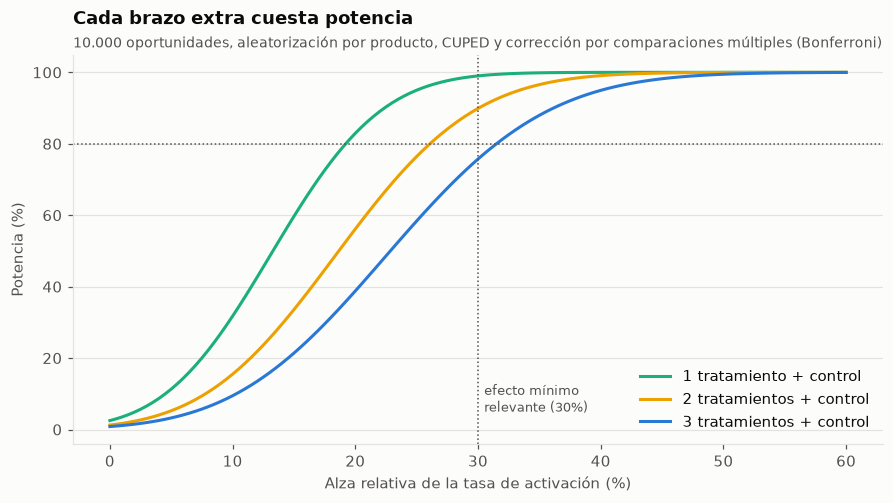

In [4]:
fig, ax = plt.subplots(figsize=(9.5, 4.6))
lifts = np.linspace(0, 0.6, 121)
for k, color in zip([1, 2, 3], [viz.SERIES[2], viz.SERIES[3], viz.EXPORT]):
    n_t = int(N / (k + np.sqrt(k))); n_c = N - k * n_t
    p1 = p0 * (1 + lifts)
    se = np.sqrt((p0 * (1 - p0) / n_c + p1 * (1 - p1) / n_t) * deff * (1 - r2))
    zc = stats.norm.ppf(1 - 0.05 / (2 * k))
    power = stats.norm.sf(zc - (p1 - p0) / se)
    ax.plot(lifts * 100, power * 100, color=color, label=f"{k} tratamiento{'s' if k > 1 else ''} + control")
ax.legend(loc="lower right")
ax.axhline(80, color=viz.TEXT_2, ls=":", lw=1)
ax.axvline(30, color=viz.TEXT_2, ls=":", lw=1)
ax.text(30.5, 5, "efecto mínimo\nrelevante (30%)", fontsize=8.5, color=viz.TEXT_2)
ax.set_xlabel("Alza relativa de la tasa de activación (%)"); ax.set_ylabel("Potencia (%)")
ax.set_title("Cada brazo extra cuesta potencia")
viz.subtitle(ax, "10.000 oportunidades, aleatorización por producto, CUPED y corrección por comparaciones múltiples (Bonferroni)")
viz.save(fig, "27_experimento_potencia"); fig

**Decisión de diseño:** con tres tratamientos el MDE planificado queda cerca del 30% que interesa al negocio,
calculado con Bonferroni, que es conservador; el análisis usa Holm, que tiene algo más de potencia. Se mantienen
los cuatro brazos. Con más brazos, o sin CUPED, el experimento no alcanzaría a detectar efectos relevantes.
También queda claro lo que este diseño **no** puede responder: distinguir entre C y D requeriría detectar una
diferencia de ~10 puntos relativos entre dos tratamientos, y para eso harían falta varias veces más
oportunidades.

## 2. Validar el procedimiento antes de usarlo: tests A/A

Un test A/A divide la población en dos grupos **sin aplicar ningún tratamiento** y compara. Como no hay efecto,
un procedimiento correcto debe declarar diferencias significativas solo el 5% de las veces. Aquí se hace con los
resultados reales del grupo control: 1.000 divisiones al azar, analizadas de dos formas.

In [5]:
R = 1000
aa = []
for s in range(R):
    arm = E.assign(u, ["A", "A2"], [1, 1], seed=s).to_numpy()
    aa.append({"ingenuo (pares independientes)": E.compare(y0, arm, cluster, "A", clustered=False).p.iloc[0],
               "agrupado por producto": E.compare(y0, arm, cluster, "A", clustered=True).p.iloc[0]})
aa = pd.DataFrame(aa)
fpr = (aa < 0.05).mean()
print("Tasa de falsos positivos en 1.000 tests A/A (debería ser 5%):")
print((fpr * 100).round(1).astype(str) + "%")
print(f"Error de simulación ±{1.96 * np.sqrt(0.05 * 0.95 / R) * 100:.1f} pp")

Tasa de falsos positivos en 1.000 tests A/A (debería ser 5%):
ingenuo (pares independientes)    8.9%
agrupado por producto             6.1%
dtype: str
Error de simulación ±1.4 pp


**Lectura:** el análisis ingenuo, que trata cada par como independiente, declara diferencias inexistentes cerca
del 9% de las veces: casi el doble de lo prometido, porque ignora que los pares de un mismo producto se mueven
juntos. Con errores agrupados por producto la tasa queda cerca del 5% (un poco por encima, dentro de lo esperable
con ~1.100 grupos). Este es el tipo de error que un test A/A detecta antes de lanzar el experimento real.

## 3. Aleatorización, SRM y balance

In [6]:
ARMS = ["A", "B", "C", "D"]
WEIGHTS = [np.sqrt(3), 1, 1, 1]
arm = E.assign(u, ARMS, WEIGHTS, seed=2026)
u["brazo"] = arm
arm = arm.to_numpy()

per_product = u.groupby("hs6").brazo.first()
srm_cluster = E.srm_test(per_product, ARMS, WEIGHTS)
srm_pairs = E.srm_test(u.brazo, ARMS, WEIGHTS)
print(f"SRM sobre la unidad aleatorizada (productos): p = {srm_cluster['p']:.3f}   {srm_cluster['observado']}")
print(f"SRM sobre los pares (unidad equivocada):     p = {srm_pairs['p']:.2g}   {srm_pairs['observado']}")

# ¿Con qué frecuencia el test sobre la unidad equivocada da una falsa alarma? 300 aleatorizaciones correctas
false_alarm = {"productos": [], "pares": []}
for s in range(300):
    b = E.assign(u, ARMS, WEIGHTS, seed=7_000 + s)
    false_alarm["pares"].append(E.srm_test(b, ARMS, WEIGHTS)["p"] < 0.001)
    false_alarm["productos"].append(E.srm_test(b.groupby(u.hs6).first(), ARMS, WEIGHTS)["p"] < 0.001)
print("Falsas alarmas de SRM (p < 0,001) en 300 aleatorizaciones sin error:",
      {k: f"{np.mean(v):.0%}" for k, v in false_alarm.items()})
E.smd(u, u.brazo, "A", E.COVARIATES).round(3)

SRM sobre la unidad aleatorizada (productos): p = 0.997   {'A': 406, 'B': 236, 'C': 232, 'D': 236}
SRM sobre los pares (unidad equivocada):     p = 0.28   {'A': 3604, 'B': 2074, 'C': 2171, 'D': 2151}


Falsas alarmas de SRM (p < 0,001) en 300 aleatorizaciones sin error: {'productos': '0%', 'pares': '38%'}


,score,log_valor_2024,log_valor_2025,meses_2024,meses_2025
C,0.041,0.101,0.066,0.060,0.028
B,0.026,0.097,0.096,0.094,0.091
D,0.061,0.061,0.028,0.022,0.013


**Lectura:**
- **SRM (Sample Ratio Mismatch):** sobre los productos, que son la unidad aleatorizada, los tamaños calzan con lo
  planificado. En esta aleatorización el test sobre los pares también pasa, pero eso es suerte: en 300
  aleatorizaciones correctas, el test sobre los pares da una **falsa alarma en más de un tercio de los casos**.
  Los productos tienen distinta cantidad de pares, así que el número de pares por brazo varía mucho más de lo que
  el test supone. **El SRM se evalúa sobre la unidad que se aleatorizó**; si no, la alarma pierde todo valor.
- **Balance:** casi todas las diferencias estandarizadas quedan bajo 0,1, el umbral usual, pero el brazo C queda
  justo en el límite en el comercio de 2024 (0,10). Con ~230 productos por brazo, desbalances así ocurren por
  azar aunque la aleatorización sea correcta. Es una de las razones para ajustar con CUPED.

## 4. Resultados del experimento

Aquí se "ejecuta" el experimento: cada brazo recibe su resultado. El control conserva su resultado real; en los
brazos tratados se inyecta el efecto supuesto, que el analista no conoce hasta la sección 7.

In [7]:
TRUE_LIFT = {"B": 0.0, "C": 0.30, "D": 0.40}   # oculto para el análisis; se revela en la sección 7
q = E.base_probability(u)
y = y0.copy()
for a, lift in TRUE_LIFT.items():
    y1 = E.potential_outcomes(y0.astype(int), q, lift, seed=ord(a)).astype(float)
    y[arm == a] = y1[arm == a]

y_cuped = E.cuped(y, X)
res = {}
for name, yy in [("sin ajuste", y), ("CUPED", y_cuped)]:
    r = E.compare(yy, arm, cluster, "A")
    r["p Holm"] = E.holm(r.p)
    r["p Dunnett"] = E.dunnett(r)
    r["ic_inf"], r["ic_sup"] = r.diferencia - 1.96 * r.se, r.diferencia + 1.96 * r.se
    res[name] = r
om = E.omnibus(y, arm, cluster)
print(f"Test global (¿todas las tasas son iguales?): Wald = {om['wald']:.1f}, gl = {om['gl']}, p = {om['p']:.2g}")
out = pd.concat(res, names=["análisis"])
out.assign(**{"tasa": out.tasa * 100, "diferencia (pp)": out.diferencia * 100, "efecto relativo": out.efecto_relativo * 100,
              "IC 95% (pp)": [f"[{a * 100:+.1f}, {b * 100:+.1f}]" for a, b in zip(out.ic_inf, out.ic_sup)]})[
    ["tasa", "diferencia (pp)", "efecto relativo", "IC 95% (pp)", "p", "p Holm", "p Dunnett"]].round(3)

Test global (¿todas las tasas son iguales?): Wald = 36.6, gl = 3, p = 5.5e-08


tasa  diferencia (pp)  efecto relativo   IC 95% (pp)      p  p Holm  p Dunnett
análisis   brazo                                                                                  
sin ajuste C      14.279            4.651           48.305  [+2.7, +6.6]  0.000   0.000      0.000
           B      11.041            1.413           14.679  [-0.4, +3.2]  0.129   0.129      0.320
           D      14.598            4.970           51.616  [+3.0, +6.9]  0.000   0.000      0.000
CUPED      C      13.939            3.806           37.561  [+2.1, +5.5]  0.000   0.000      0.000
           B      10.635            0.502            4.955  [-1.2, +2.2]  0.566   0.566      0.908
           D      14.488            4.356           42.985  [+2.5, +6.2]  0.000   0.000      0.000

**Lectura (con el análisis preregistrado: CUPED + Holm):**
- **Test global:** las tasas no son todas iguales. Pero este test no dice cuál brazo difiere; para eso están las
  comparaciones contra el control.
- **C (rueda de negocios) y D (rueda + misión)** superan al control con p ajustados bajo 0,05.
- **B (alerta informativa)** no se distingue del control.
- **CUPED** hace dos cosas. Angosta los intervalos y, en esta ejecución, además **corrige el desbalance por azar**
  de la sección 3: el brazo C había recibido oportunidades con algo más de comercio previo, y sin ajuste su
  efecto aparece inflado (+48% relativo). Con CUPED baja a +38%, más cerca del efecto verdadero que se revela en la
  sección 7. En promedio sobre muchas aleatorizaciones las dos estimaciones son insesgadas, pero en un
  experimento concreto, que es el único que se ejecuta, el ajuste protege contra la mala suerte.
- **Holm vs Dunnett:** Dunnett aprovecha que las tres comparaciones comparten el mismo control. Holm, en cambio,
  es secuencial: una vez que rechaza el efecto más fuerte, prueba los siguientes con un umbral menos exigente.
  Cuando hay varios efectos reales, Holm puede terminar siendo más potente que Dunnett en su versión de un paso.

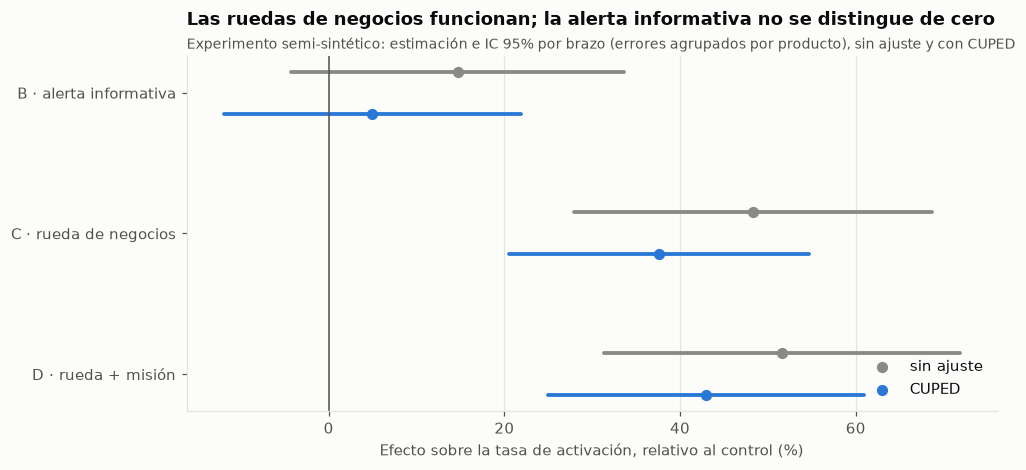

In [8]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
yy_pos = {"B": 2, "C": 1, "D": 0}
for name, off, color in [("sin ajuste", 0.15, viz.NEUTRAL), ("CUPED", -0.15, viz.EXPORT)]:
    r = res[name]
    for a, row in r.iterrows():
        rel, lo, hi = (row.diferencia / row.tasa_control * 100, row.ic_inf / row.tasa_control * 100, row.ic_sup / row.tasa_control * 100)
        ax.plot([lo, hi], [yy_pos[a] + off] * 2, color=color, lw=2.5, solid_capstyle="round")
        ax.scatter([rel], [yy_pos[a] + off], color=color, s=40, zorder=3, label=name if a == "B" else None)
ax.axvline(0, color=viz.TEXT_2, lw=1)
ax.set_yticks([2, 1, 0], ["B · alerta informativa", "C · rueda de negocios", "D · rueda + misión"])
ax.grid(axis="y", visible=False); ax.grid(axis="x")
ax.set_xlabel("Efecto sobre la tasa de activación, relativo al control (%)")
ax.legend(loc="lower right")
ax.set_title("Las ruedas de negocios funcionan; la alerta informativa no se distingue de cero")
viz.subtitle(ax, "Experimento semi-sintético: estimación e IC 95% por brazo (errores agrupados por producto), sin ajuste y con CUPED")
viz.save(fig, "28_experimento_resultados"); fig

## 5. Heterogeneidad: ¿funciona mejor en las oportunidades más prometedoras?

Por cómo se construyó el escenario, el efecto absoluto es mayor donde la probabilidad base es mayor. Explorarlo
es útil para focalizar, pero **no estaba en el preregistro**: se reporta como exploratorio, porque partir los
datos en subgrupos multiplica las comparaciones y la probabilidad de encontrar algo por azar.

In [9]:
u["mitad"] = np.where(u.score >= u.score.median(), "puntaje alto", "puntaje bajo")
het = []
for h, g in u.groupby("mitad"):
    m = (u.mitad == h).to_numpy()
    r = E.compare(y_cuped[m], arm[m], cluster[m], "A")
    het += [{"subgrupo": h, "brazo": a, "diferencia (pp)": row.diferencia * 100, "se (pp)": row.se * 100} for a, row in r.iterrows()]
pd.DataFrame(het).pivot(index="brazo", columns="subgrupo").round(2)

diferencia (pp)                   se (pp)             
subgrupo    puntaje alto puntaje bajo puntaje alto puntaje bajo
brazo                                                          
B                   1.66        -0.57         1.41         1.09
C                   6.61         1.10         1.42         1.13
D                   6.83         1.91         1.43         1.12

## 6. El problema de mirar antes de tiempo (*peeking*)

Una agencia real querría revisar los resultados cada mes y detener el experimento apenas algo "salga
significativo". El resultado se acumula mes a mes (los datos tienen la trayectoria real de cada par), así que se
puede simular exactamente esa conducta en tests A/A: sin efecto, revisar 8 veces con el umbral de 1,96 y
detenerse en el primer resultado significativo.

La corrección estándar son **fronteras de O'Brien–Fleming**: muy exigentes al principio (cuando hay poca
información) y cercanas a 1,96 al final. Se calibran para que la probabilidad total de un falso positivo, sumando
todas las revisiones, sea 5%.

In [10]:
bounds = E.obf_bounds(len(months))
print("Fronteras O'Brien–Fleming por mes:", " ".join(f"{b:.2f}" for b in bounds))
paths = []
for s in range(R):
    a2 = E.assign(u, ["A", "A2"], [1, 1], seed=10_000 + s).to_numpy()
    paths.append([E.compare(u[mo].to_numpy().astype(float), a2, cluster, "A").z.iloc[0] for mo in months])
paths = np.array(paths)
peek = {"solo al final (preregistrado)": (np.abs(paths[:, -1]) > 1.96).mean(),
        "cada mes con 1,96 (peeking)": (np.abs(paths) > 1.96).any(axis=1).mean(),
        "cada mes con O'Brien–Fleming": (np.abs(paths) >= bounds).any(axis=1).mean()}
print("Tasa de falsos positivos en 1.000 tests A/A con revisiones mensuales:")
for k, v in peek.items():
    print(f"  {k:32s} {v:.1%}")

Fronteras O'Brien–Fleming por mes: 5.85 4.13 3.38 2.92 2.62 2.39 2.21 2.07


Tasa de falsos positivos en 1.000 tests A/A con revisiones mensuales:
  solo al final (preregistrado)    5.4%
  cada mes con 1,96 (peeking)      17.0%
  cada mes con O'Brien–Fleming     5.6%


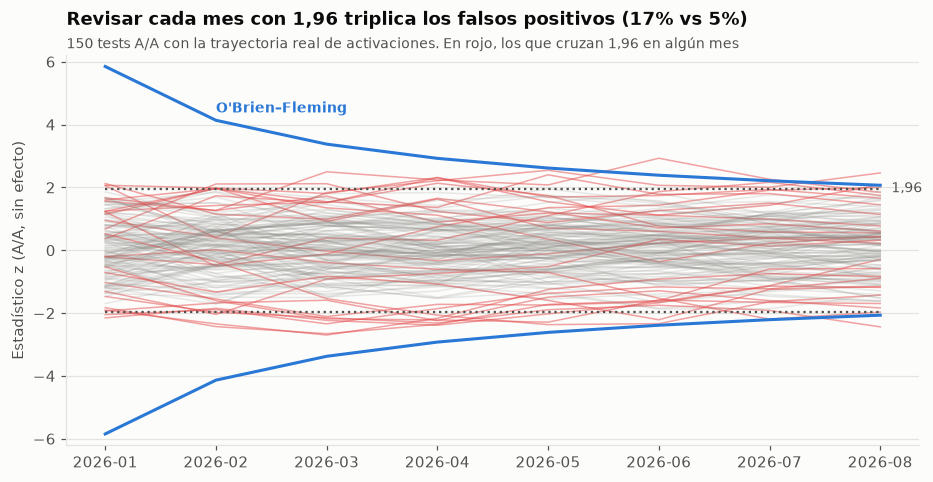

In [11]:
fig, ax = plt.subplots(figsize=(10, 4.6))
x = np.arange(1, len(months) + 1)
for path in paths[:150]:
    crossed = (np.abs(path) > 1.96).any()
    ax.plot(x, path, color=viz.SERIES[7] if crossed else viz.NEUTRAL, alpha=0.5 if crossed else 0.18, lw=1)
for sign in (1, -1):
    ax.plot(x, sign * np.full(len(x), 1.96), color=viz.TEXT_2, ls=":", lw=1.5)
    ax.plot(x, sign * bounds, color=viz.EXPORT, lw=2)
ax.text(x[-1] + 0.1, 1.96, "1,96", color=viz.TEXT_2, va="center", fontsize=9)
ax.text(x[1], bounds[1] + 0.25, "O'Brien–Fleming", color=viz.EXPORT, fontsize=9, fontweight="bold")
ax.set_ylim(-6.2, 6.2)
ax.set_xticks(x, [m.replace("activa_", "") for m in months])
ax.set_ylabel("Estadístico z (A/A, sin efecto)")
ax.set_title(f"Revisar cada mes con 1,96 triplica los falsos positivos ({peek['cada mes con 1,96 (peeking)']:.0%} vs 5%)")
viz.subtitle(ax, "150 tests A/A con la trayectoria real de activaciones. En rojo, los que cruzan 1,96 en algún mes")
viz.save(fig, "29_experimento_peeking"); fig

**Lectura:** revisar cada mes con el umbral habitual eleva los falsos positivos a ~17%, más del triple de lo
prometido. Con las fronteras de O'Brien–Fleming vuelve a ~5%, y aun así permite detener temprano un efecto muy
grande. La alternativa más simple es la que se preregistró: mirar una sola vez, al final.

## 7. Revelar la verdad: ¿el procedimiento recupera los efectos?

Como el efecto se inyectó, se puede comparar lo estimado con lo verdadero. Una sola ejecución no basta para
juzgar un procedimiento, así que se repite el experimento completo 500 veces (nueva aleatorización y nuevos
efectos simulados en cada repetición, siempre sobre los mismos resultados reales del control).

In [12]:
print("Efectos verdaderos (relativos):", {k: f"{v:.0%}" for k, v in TRUE_LIFT.items()})
mc = []
for s in range(500):
    a_s = E.assign(u, ARMS, WEIGHTS, seed=50_000 + s).to_numpy()
    y_s = y0.copy()
    true_diff = {}
    for a, lift in TRUE_LIFT.items():
        y1 = E.potential_outcomes(y0.astype(int), q, lift, seed=s * 10 + ord(a)).astype(float)
        y_s[a_s == a] = y1[a_s == a]
        true_diff[a] = y1.mean() - y0.mean()
    for name, yy in [("sin ajuste", y_s), ("CUPED", E.cuped(y_s, X))]:
        r = E.compare(yy, a_s, cluster, "A")
        r["p_holm"] = E.holm(r.p)
        for a, row in r.iterrows():
            mc.append({"análisis": name, "brazo": a, "dif": row.diferencia, "se": row.se, "p_holm": row.p_holm,
                       "cubre": abs(row.diferencia - true_diff[a]) <= 1.96 * row.se, "verdad": true_diff[a]})
mc = pd.DataFrame(mc)
summary = mc.groupby(["análisis", "brazo"]).agg(
    efecto_verdadero_pp=("verdad", lambda v: v.mean() * 100), estimado_pp=("dif", lambda v: v.mean() * 100),
    rechaza_H0=("p_holm", lambda p: (p < 0.05).mean()), cobertura_IC95=("cubre", "mean"), se_pp=("se", lambda v: v.mean() * 100))
summary.round(3)

Efectos verdaderos (relativos): {'B': '0%', 'C': '30%', 'D': '40%'}


efecto_verdadero_pp  estimado_pp  rechaza_H0  cobertura_IC95  se_pp
análisis   brazo                                                                     
CUPED      B                    0.000        0.008       0.054           0.944  0.862
           C                    3.250        3.282       0.926           0.956  0.914
           D                    4.343        4.350       0.992           0.950  0.920
sin ajuste B                    0.000        0.030       0.048           0.946  0.927
           C                    3.250        3.262       0.870           0.948  0.986
           D                    4.343        4.364       0.972           0.936  0.997

**Lectura:**
- **Sin sesgo:** el efecto estimado promedio coincide con el verdadero en los tres brazos.
- **Cobertura:** los intervalos de 95% contienen el efecto verdadero cerca del 95% de las veces.
- **Potencia real:** con CUPED, el brazo C (efecto verdadero +30%) se detecta en ~93% de las repeticiones, más que
  el 80% planificado, porque Bonferroni y la estratificación hicieron conservador el cálculo inicial. Sin CUPED,
  ~87%.
- **Error tipo I:** el brazo B no tiene efecto, y se declara significativo en ~5% de las repeticiones, lo que
  promete Holm.

## 8. Decisión de negocio

El objetivo no es un p-value sino una decisión: qué apoyo escalar. La métrica de decisión es el **costo por
activación adicional** = costo por oportunidad / alza absoluta de la tasa.

In [13]:
COST = {"B": 50, "C": 1_500, "D": 4_000}
r = res["CUPED"].reindex(list(COST))
dec = pd.DataFrame({"costo por oportunidad (US$)": pd.Series(COST),
                    "alza (pp)": r.diferencia * 100, "IC 95% inf (pp)": r.ic_inf * 100, "IC 95% sup (pp)": r.ic_sup * 100})
dec["costo por activación adicional (US$)"] = np.where(r.ic_inf > 0, dec["costo por oportunidad (US$)"] / r.diferencia, np.nan)
dec["rango con el IC (US$)"] = [f"{c / hi:,.0f} – {c / lo:,.0f}" if lo > 0 else "alza no distinguible de cero"
                                for c, lo, hi in zip(dec["costo por oportunidad (US$)"], r.ic_inf, r.ic_sup)]
med_value = pd.read_parquet(E.PROCESSED / "activacion_test_scores.parquet").sort_values("score", ascending=False).head(len(u))
med_value = med_value.loc[med_value.activa == 1, "valor_target"]
print(f"Valor exportado por un par activado en 8 meses: mediana US$ {med_value.median():,.0f}, promedio US$ {med_value.mean():,.0f}")
dec.round(1)

Valor exportado por un par activado en 8 meses: mediana US$ 33,004, promedio US$ 195,043


,costo por oportunidad (US$),alza (pp),IC 95% inf (pp),IC 95% sup (pp),costo por activación adicional (US$),rango con el IC (US$)
B,50,0.5,-1.2,2.2,NaN,alza no distinguible de cero
C,1500,3.8,2.1,5.5,39412.4,"27,096 – 72,255"
D,4000,4.4,2.5,6.2,91836.2,"64,728 – 158,013"


**Lectura y recomendación:**
- **B (alerta):** es casi gratis, pero no tiene un efecto distinguible de cero. No se escala por evidencia, aunque
  un efecto pequeño no está descartado; si se quisiera medir, haría falta un experimento propio con mucha más
  muestra.
- **C (rueda de negocios):** cada activación adicional cuesta varias decenas de miles de dólares. Es más que la
  mediana de lo que exporta un par activado en sus primeros 8 meses, pero bastante menos que el promedio, y una
  exportación nueva suele crecer después del primer año. Es el candidato a escalar.
- **D (rueda + misión):** su alza no se distingue de la de C (el diseño no tenía potencia para separarlas) y
  cuesta casi tres veces más. **Sin evidencia de que rinda más, se elige la opción más barata.**

## 9. Limitaciones
- **El efecto es un supuesto.** El notebook demuestra que el diseño y el análisis funcionan, no que las campañas
  funcionen. En un experimento real, el efecto sería la incógnita.
- **Forma del efecto.** Se supuso un alza proporcional a la probabilidad base. Si el apoyo ayudara más a las
  oportunidades débiles, la potencia y la heterogeneidad cambiarían.
- **Interferencia residual.** Aleatorizar por producto evita el contagio entre destinos de un mismo producto,
  pero no entre productos relacionados (la red del notebook 02 muestra que comparten exportadores). Un diseño más
  estricto aleatorizaría por comunidad de la red, a costa de mucha más varianza.
- **Costos supuestos** y una métrica de valor (exportaciones) que no es el beneficio neto para el país.
- **Una sola métrica de resguardo posible.** En un programa real se monitorearían métricas como la satisfacción de
  los exportadores o el costo operativo, que no existen en estos datos.

## 10. Conclusiones
1. **Diseño:** con 10.000 oportunidades, aleatorización por producto y CUPED, tres tratamientos alcanzan a
   detectar alzas de ~30%. Un cuarto tratamiento ya no habría alcanzado.
2. **Validación:** los tests A/A con datos reales mostraron que un análisis que ignora los grupos casi duplica los
   falsos positivos (9% vs 5%), y que revisar cada mes los triplica (17%). Ambos problemas se corrigieron antes
   del análisis.
3. **Resultado (simulado):** las ruedas de negocios funcionan y la alerta informativa no se distingue de cero.
   Entre C y D no hay evidencia para pagar casi el triple.
4. **Método:** con el efecto verdadero conocido, el procedimiento resultó insesgado, con cobertura cercana al 95% y
   error tipo I controlado en el brazo sin efecto.